In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/bibhushaojha/Desktop/Agri/outputs/panel/agri_trends_panel_2016_2025_weekly_FL.csv",
                 index_col=0, parse_dates=True)
print(df.shape)
df.head()

(523, 49)


,Strawberry,Blueberry,Watermelon,Cucumber,Tomato,Potato,Lime,Bell Pepper,Cabbage,Guava,...,Parsley,Mint,Rosemary,Basil,Onion,Garlic,Spinach,Banana,Broccoli,Cauliflower
Date,,,,,,,,,,,,,,,,,,,,,
2015-12-27,7.556257,2.833596,1.889064,3.778129,15.112514,15.697037,3.622393,3.622393,4.226125,1.041587,...,0.839807,0.098801,1.679613,2.074816,7.053636,6.171931,4.996325,10.874355,4.702424,1.910360
2016-01-03,8.028523,2.833596,1.889064,3.305862,14.167982,15.093304,3.622393,4.226125,4.226125,0.867989,...,0.988008,0.148201,1.432611,1.976015,6.759734,5.878030,4.555473,10.874355,5.731079,3.085966
2016-01-10,8.973055,3.305862,1.889064,2.833596,12.751184,14.489572,3.018661,4.226125,3.622393,0.867989,...,0.839807,0.148201,1.185609,1.827814,6.318882,5.731079,4.261572,10.874355,5.437178,3.526818
2016-01-17,8.973055,3.305862,1.889064,3.778129,13.695716,16.300769,3.018661,4.829857,3.622393,0.867989,...,0.889207,0.148201,1.432611,2.074816,6.906685,6.171931,4.408522,11.315208,6.024981,4.114621
2016-01-24,10.389853,3.778129,1.889064,3.305862,12.751184,15.093304,3.018661,3.622393,3.622393,1.041587,...,0.839807,0.148201,1.383211,1.729013,6.465833,6.024981,4.261572,11.462158,5.731079,4.114621


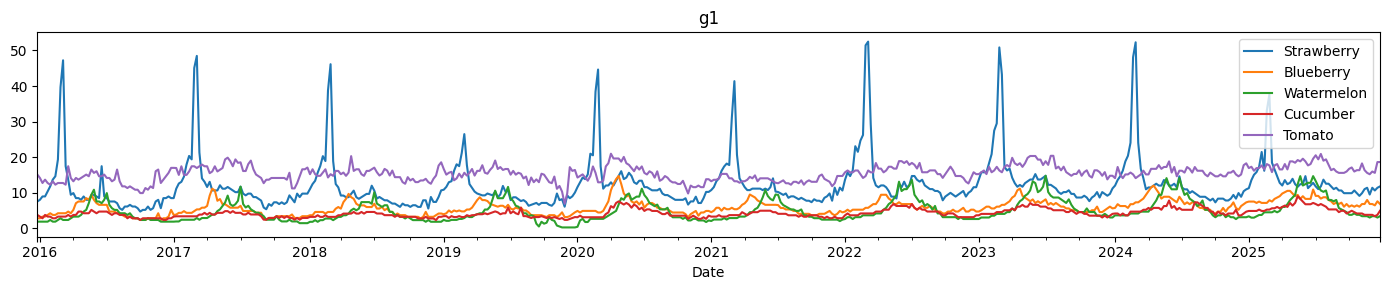

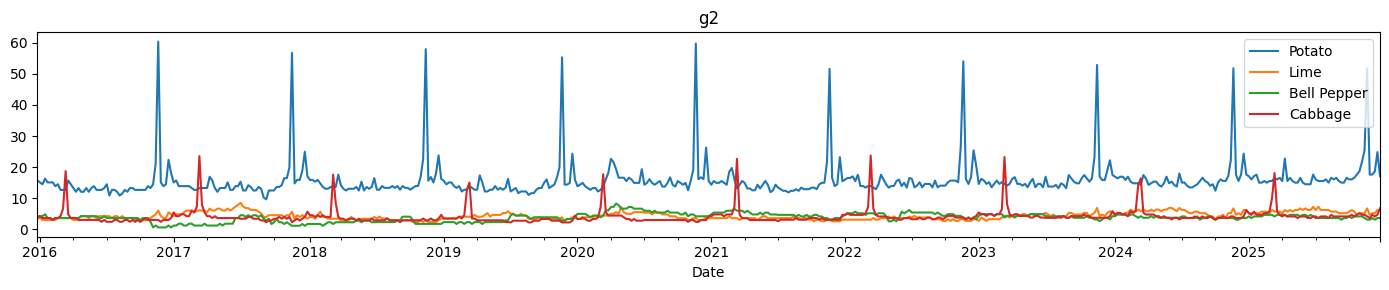

In [4]:
groups = {
    "g1": ["Strawberry","Blueberry","Watermelon","Cucumber","Tomato"],
    "g2": ["Potato","Lime","Bell Pepper","Cabbage"],
    # ... fill in for g3–g12
}
for gname, crops in groups.items():
    cols = [c for c in crops if c.title() in df.columns]
    df[cols].plot(figsize=(14,3), title=gname)
    plt.tight_layout(); plt.savefig(f"../outputs/figures/panel_{gname}.png", dpi=120)
    plt.show()

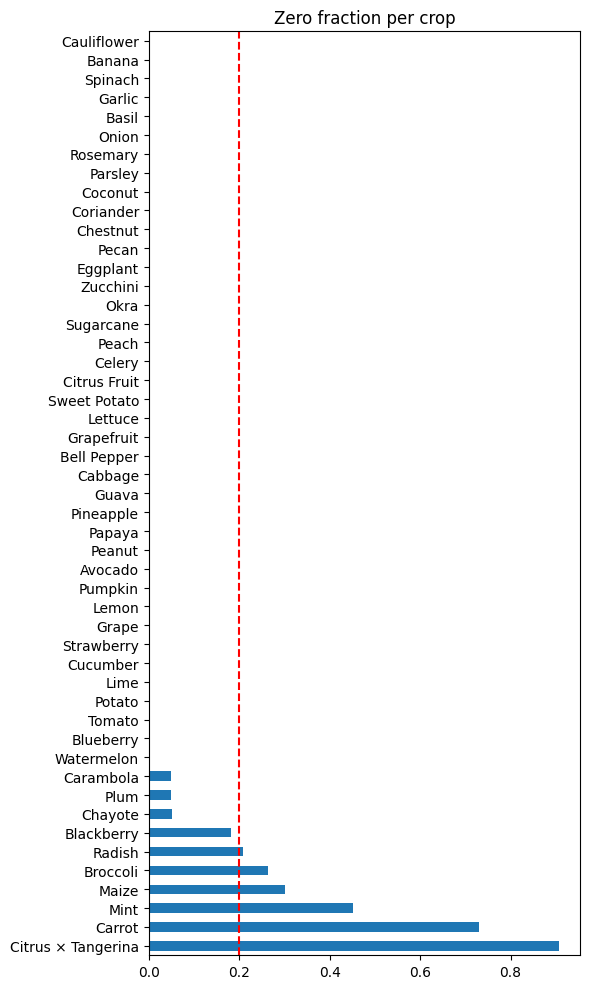

In [7]:
# data-quality plot showing how much of each crop’s Google Trends time series is zero or missing
zfrac = (df.fillna(0) <= 0).mean().sort_values(ascending=False)
zfrac.plot.barh(figsize=(6,10), title="Zero fraction per crop")
plt.axvline(0.20, color='red', linestyle='--', label='gate')
plt.tight_layout(); plt.savefig("../outputs/figures/zero_fraction.png", dpi=150)

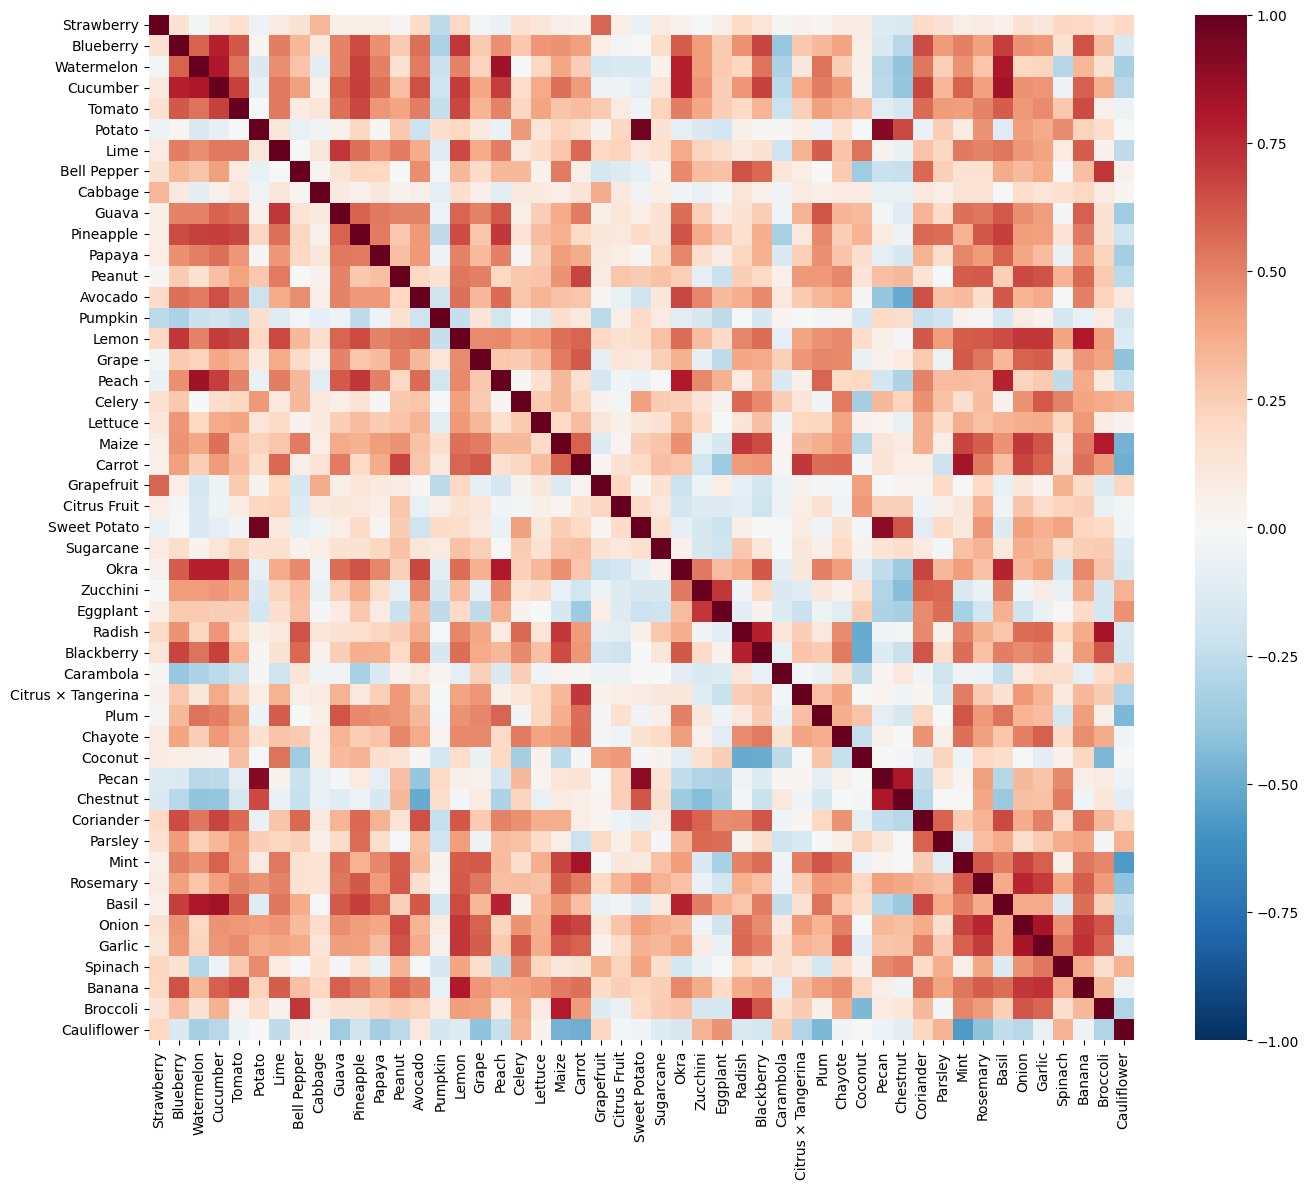

In [6]:
# correlation matrix
corr = df.corr()
import seaborn as sns
fig, ax = plt.subplots(figsize=(14,12))
sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.tight_layout(); plt.savefig("../outputs/figures/corr_raw.png", dpi=150)